# Tarea 1 DAML - Cristóbal Vergara Jofré

#Ejecutada con kernel python 3.11.9

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.


In [17]:
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

In [18]:
df = pd.read_csv("../../../data/student_productivity.csv")
initial_count = len(df)
print(f"Filas antes de la limpieza: {initial_count}")

Filas antes de la limpieza: 5621



--- Nulos Restantes por Columna ---
                      Cantidad Nulos  % del Total
drug_use                        4103        72.99
upcoming_deadline                717        12.76
burnout_level                    716        12.74
exam_score                       709        12.61
part_time_job                    703        12.51
online_classes_hours             682        12.13
mental_health_score              675        12.01
self_study_hours                 667        11.87
gaming_hours                     656        11.67
social_media_hours               656        11.67
age                              648        11.53
productivity_score               638        11.35
focus_index                      633        11.26
academic_level                   630        11.21
caffeine_intake_mg               600        10.67
exercise_minutes                 599        10.66
screen_time_hours                586        10.43
study_hours                      574        10.21
gender       

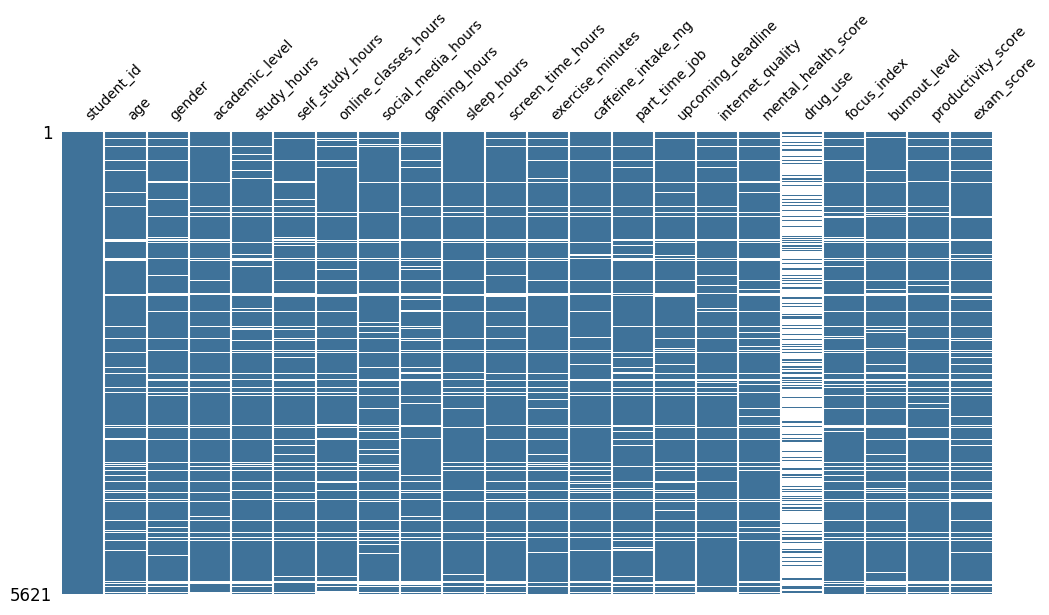

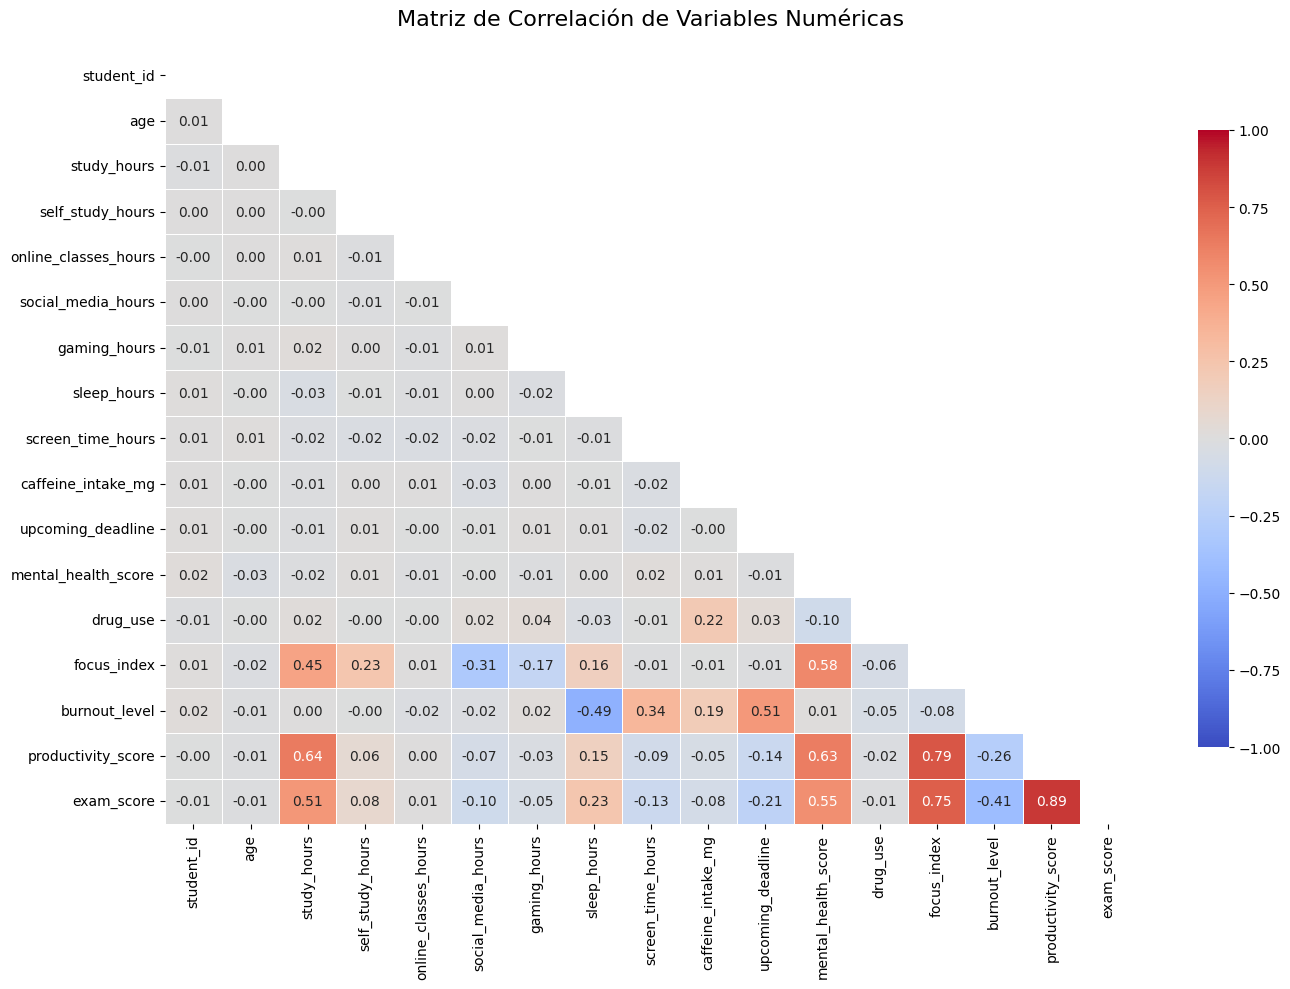


--- Verificación de Rangos Lógicos ---
  ✓ 'age': Rangos OK.
  ✓ 'self_study_hours': Rangos OK.
  ✓ 'sleep_hours': Rangos OK.
  ✓ 'caffeine_intake_mg': Rangos OK.
  ✓ 'mental_health_score': Rangos OK.
  ✓ 'exam_score': Rangos OK.

--- Estadísticas Descriptivas (Variables Numéricas) ---
                       count     mean      std   min      25%      50%  \
student_id            5621.0  2811.00  1622.79   1.0  1406.00  2811.00   
age                   4973.0    20.51     2.88  16.0    18.00    20.00   
study_hours           5047.0     4.54     1.82   0.0     3.26     4.53   
self_study_hours      4954.0     2.48     1.18   0.0     1.66     2.48   
online_classes_hours  4939.0     2.01     0.98   0.0     1.32     2.01   
social_media_hours    4965.0     3.00     1.47   0.0     2.00     2.99   
gaming_hours          4965.0     1.57     1.11   0.0     0.68     1.50   
sleep_hours           5068.0     7.02     1.16   4.0     6.25     7.02   
screen_time_hours     5035.0     6.98     2.48

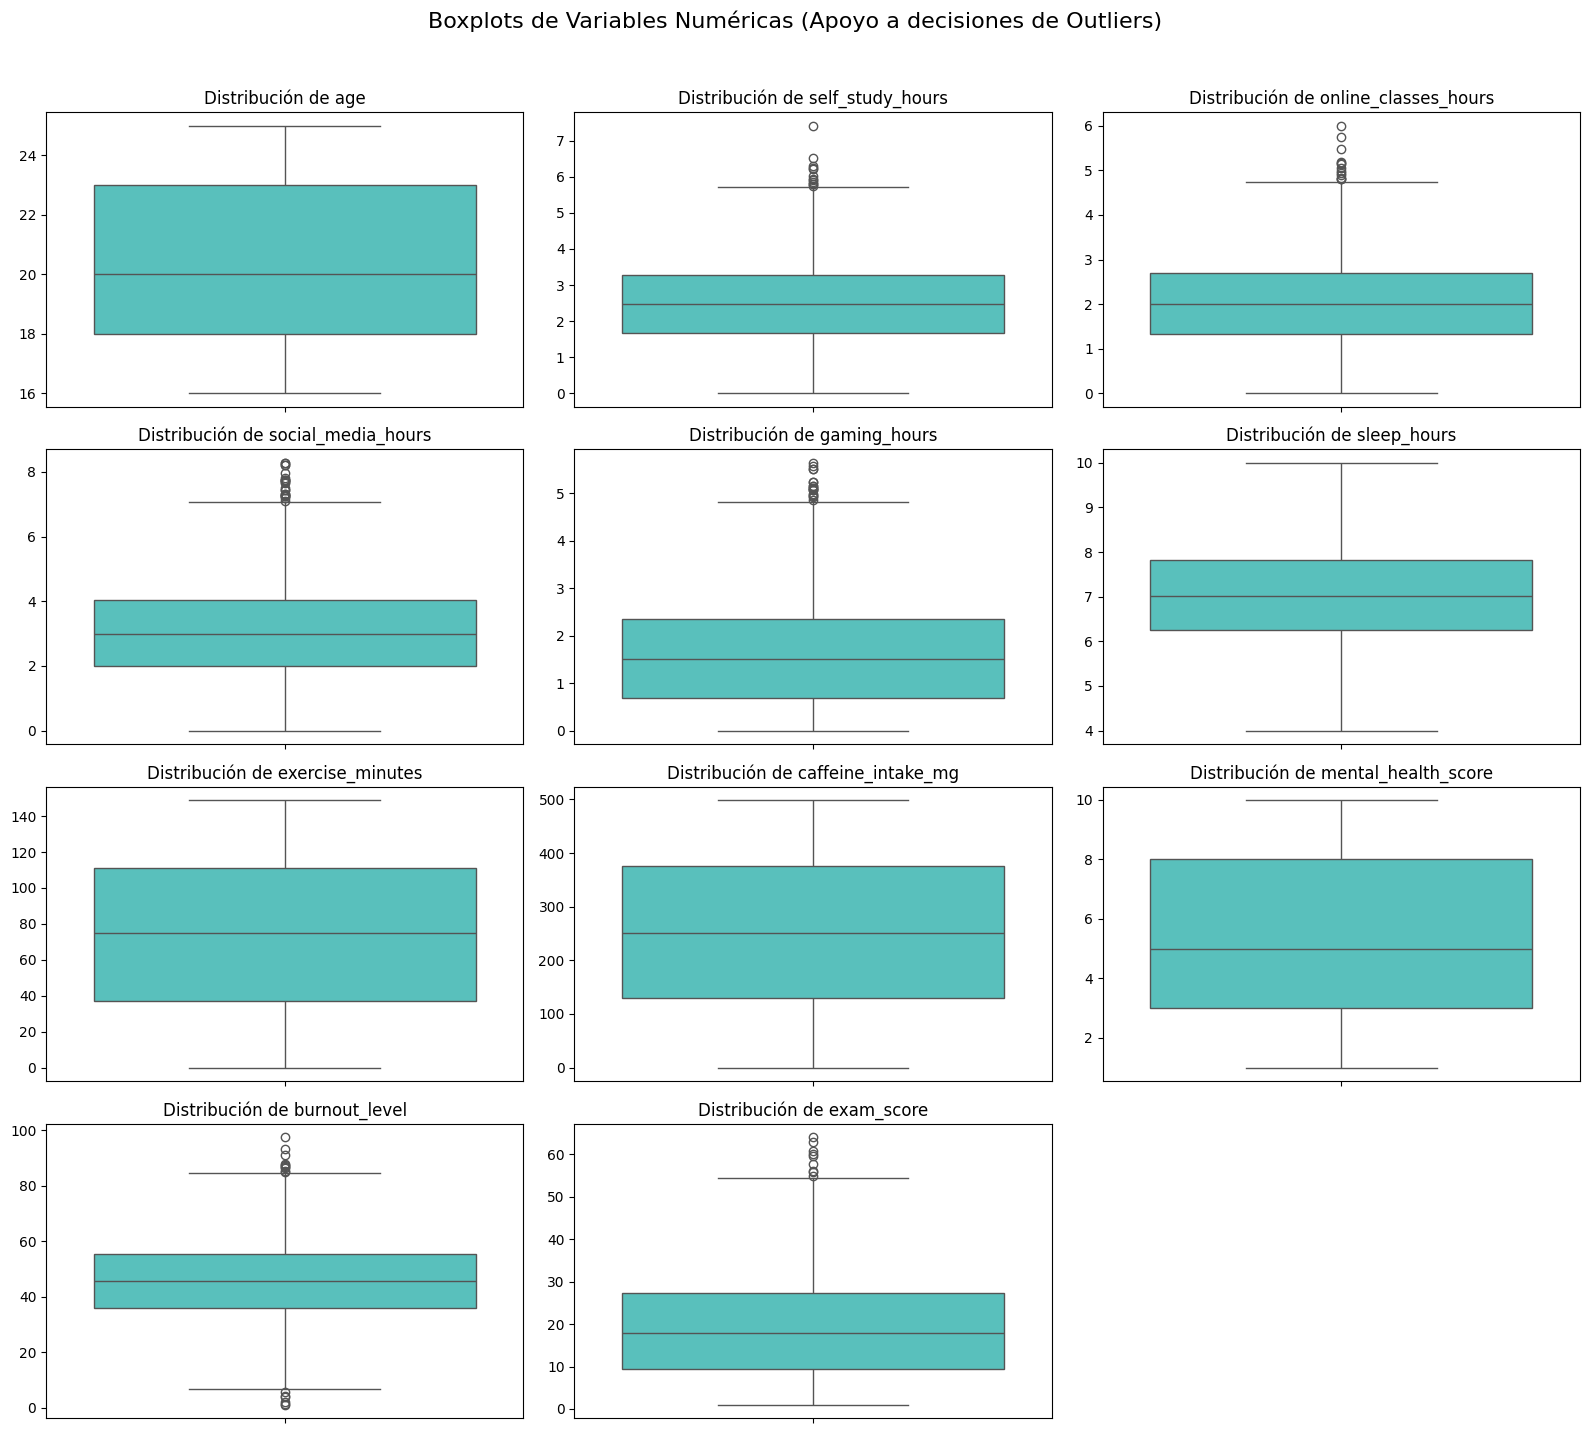


--- Detección Numérica de Outliers (Método IQR) ---
            Variable  Outliers  % del Total  Límite Inferior  Límite Superior
  social_media_hours        23         0.46            -1.05             7.08
        gaming_hours        18         0.36            -1.82             4.86
       burnout_level        16         0.33             6.31            84.87
online_classes_hours        13         0.26            -0.73             4.74
    self_study_hours        12         0.24            -0.77             5.71
          exam_score         9         0.18           -17.59            54.41


In [19]:
# --------------------------------------------------------------------------------------------------------------------------#
#--------------------------------------------Exploracion--------------------------------------------------------------------#

# 2.1 Resumen de nulos restantes
print("\n--- Nulos Restantes por Columna ---")
null_counts = df.isnull().sum()
if null_counts.sum() > 0:
    # Filtramos solo las columnas que tienen nulos
    nulls = null_counts[null_counts > 0]
    # Calculamos el porcentaje
    nulls_pct = (nulls / len(df)) * 100
    
    # Creamos un DataFrame para mostrar ambos tabulados y lo ordenamos de mayor a menor
    resume_nulos = pd.DataFrame({
        'Cantidad Nulos': nulls,
        '% del Total': nulls_pct.round(2)
    }).sort_values(by='Cantidad Nulos', ascending=False)
    
    # Mostramos la tabla
    print(resume_nulos)
    
    # Gráfico Visual de Nulos usando missingno
    msno.matrix(df, figsize=(12, 6), sparkline=False, fontsize=10, color=(0.25, 0.45, 0.6))
    
    plt.show()
else:
    print("  ✓ No hay valores nulos en el dataset.")
# 1. Filtramos solo las columnas numéricas para poder calcular la correlación
num_cols = df.select_dtypes(include=[np.number])
# 2. Calculamos la matriz de correlación de Pearson
corr = num_cols.corr()
# 3. Creamos una máscara para el triángulo superior (para no repetir datos y que se vea igual a tu foto)
mask = np.triu(np.ones_like(corr, dtype=bool))
# 4. Configuramos el tamaño de la figura
plt.figure(figsize=(14, 10))
# 5. Generamos el Heatmap con Seaborn
sns.heatmap(corr, 
            mask=mask, 
            cmap='coolwarm',      # Escala de colores (Rojo = Positivo, Azul = Negativo)
            vmin=-1, vmax=1,      # Fijar los bordes de la escala de correlación 
            annot=True,           # Mostrar el número encima
            fmt=".2f",            # 2 decimales, como en tu imagen
            linewidths=.5,        # Margen o separación visual entre los cuadritos
            cbar_kws={"shrink": .8}) # Achicar la barra lateral sutilmente
# 6. Agregamos el título y ajustamos los bordes
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, pad=20)
plt.tight_layout()
# Mostrar el gráfico
plt.show()
# 2.2 Verificación de rangos lógicos (Sanity Check)
print("\n--- Verificación de Rangos Lógicos ---")
rangos_validos = {
    'age': (10, 80), 
    'self_study_hours': (0, 24), 
    'sleep_hours': (0, 24),
    'caffeine_intake_mg': (0, 1000), 
    'mental_health_score': (1, 10),
    'exam_score': (1, 100)
}
for col, (vmin, vmax) in rangos_validos.items():
    if col in df.columns:
        n_fuera = ((df[col] < vmin) | (df[col] > vmax)).sum()
        if n_fuera > 0:
            print(f"  ⚠ '{col}': {n_fuera} valores fuera de rango ({vmin}-{vmax}).")
        else:
            print(f"  ✓ '{col}': Rangos OK.")
# 2.3 Estadísticas Descriptivas Finales
print("\n--- Estadísticas Descriptivas (Variables Numéricas) ---")
print(df.describe().T.round(2))
print("\n--- Distribución de Variables Categóricas ---")
cat_cols = ['gender', 'academic_level', 'part_time_job', 'internet_quality']
for col in cat_cols:
    if col in df.columns:
        print(f"\n[{col}]")
        print(df[col].value_counts(dropna=False))
# Variables definidas para análisis de outliers y distribuciones
num_cols_for_outliers = [
    'age', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 
    'gaming_hours', 'sleep_hours', 'exercise_minutes', 'caffeine_intake_mg', 
    'mental_health_score', 'burnout_level', 'exam_score'
]
# 2.4 Visualización de Distribuciones (Boxplots)
print("\n--- Visualización de Distribuciones (Boxplots) ---")
# Creamos una grilla de gráficos de tamaño dinámico
num_plots = len(num_cols_for_outliers)
fig, axes = plt.subplots(nrows=int(np.ceil(num_plots/3)), ncols=3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols_for_outliers):
    if col in df.columns:
        # Aseguramos formato numérico
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Dibujamos un Boxplot
        sns.boxplot(y=df[col], ax=axes[i], color='mediumturquoise')
        axes[i].set_title(f"Distribución de {col}", fontsize=12)
        axes[i].set_ylabel('')
# Ocultamos ejes sobrantes si la cantidad de variables no es múltiplo de 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots de Variables Numéricas (Apoyo a decisiones de Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
# 2.5 Detección de Outliers (Método de Rango Intercuartílico - IQR)
print("\n--- Detección Numérica de Outliers (Método IQR) ---")
outliers_summary = []
for col in num_cols_for_outliers:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Ojo: No consideramos límite inferior si cae por debajo de 0 y la variable no permite negativos
        outliers_mask = ((df[col] < lower_bound) | (df[col] > upper_bound))
        num_outliers = outliers_mask.sum()
        pct_outliers = (num_outliers / len(df[col].dropna())) * 100
        
        if num_outliers > 0:
            outliers_summary.append({
                'Variable': col,
                'Outliers': num_outliers,
                '% del Total': round(pct_outliers, 2),
                'Límite Inferior': round(lower_bound, 2),
                'Límite Superior': round(upper_bound, 2)
            })
if outliers_summary:
    df_outliers = pd.DataFrame(outliers_summary).sort_values(by='Outliers', ascending=False)
    print(df_outliers.to_string(index=False))
else:
    print("  ✓ No se detectaron outliers bajo el método IQR.")
#--------------------------------------------Exploracion--------------------------------------------------------------------#    
# --------------------------------------------------------------------------------------------------------------------------#

In [20]:
#Limpieza strings quitar " min" y pasar a float exercise minutes
if df['exercise_minutes'].dtype == 'object':
    df['exercise_minutes'] = df['exercise_minutes'].str.replace(' min', '', regex=False).astype(float)

# Estandarización de texto (minúsculas, sin espacios extra) para evitar duplicados
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)

# 1.3 Eliminación de filas basura
# Filas con demasiados nulos (>= 12) 
df['null_count_row'] = df.isnull().sum(axis=1)
df.drop(index=df[df['null_count_row'] >= 12].index, inplace=True)
df.drop(columns=['null_count_row'], inplace=True)

# 1.4 Eliminación de variables problemáticas (Multicolinealidad, Endogeneidad y Ruido)
cols_to_drop = [
    'drug_use',           # Eliminada por exceso de nulos (>70%)
    'productivity_score', # Endogeneidad severa (es una variable de resultado, no predictora) (se observa en heatmap)
    'focus_index'         # Subjetiva y altamente correlacionada con otras variables de input (se observa en heatmap)
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [21]:
# 1.5 Tratamiento de Nulos
# Numéricas: imputar con mediana
for col in ['age', 'exercise_minutes', 'caffeine_intake_mg']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Categórica (estructural): imputar con moda
if 'internet_quality' in df.columns:
    df['internet_quality'] = df['internet_quality'].fillna(df['internet_quality'].mode()[0])

# Categóricas (demográficas): Tratamiento específico para evitar dummies basura
if 'gender' in df.columns:
    # Agrupamos los nulos (y futuros 'unknown') directamente en 'other'
    df['gender'] = df['gender'].fillna('other')

# 1.5.2 Variables Part time job y deadline: Método Missing indicator
for col in ['part_time_job', 'upcoming_deadline']:
    if col in df.columns:
        # 1. Crear variable binaria indicadora de nulo
        df[f'{col}_missing'] = np.where(df[col].isnull(), 1, 0)
        
        # 2. Rellenar los nulos en la columna original con 0
        df[col] = df[col].fillna(0)
        
        # 3. Estandarizar categóricas a numéricas estrictas (0 y 1) para econometría
        if col == 'part_time_job':
            # Mapeamos 'yes' a 1. 'no' y los 0s recién imputados quedan como 0.
            df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)
df['upcoming_deadline'] = df['upcoming_deadline'].astype(int)

C:\Users\crist\AppData\Local\Temp\ipykernel_18620\569716481.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0}).astype(int)


In [22]:
#Quitamos nulos de variable dependiente
df.dropna(subset=['exam_score'], inplace=True)
# Paso B: Crear la variable binaria rindio_examen
df['rindio_examen'] = np.where(df['exam_score'] == 1.0, 0, 1)

In [23]:
df.dropna(inplace=True) #dropna general

final_count = len(df)
print(f"Filas después de la limpieza: {final_count} (Se eliminaron {initial_count - final_count} filas en total)")
print(df.head(2))
print(df.tail(2))

Filas después de la limpieza: 4163 (Se eliminaron 1458 filas en total)
   student_id   age  gender academic_level  study_hours  self_study_hours  \
0           1  20.0   other  undergraduate         5.37              2.09   
1           2  16.0  female    high school         5.85              5.04   

   online_classes_hours  social_media_hours  gaming_hours  sleep_hours  ...  \
0                  1.85                3.66          2.32         7.73  ...   
1                  1.87                3.60          2.79         6.11  ...   

   caffeine_intake_mg  part_time_job  upcoming_deadline  internet_quality  \
0               475.0              0                  0              good   
1               362.0              0                  0              good   

   mental_health_score burnout_level  exam_score  part_time_job_missing  \
0                  3.0         31.77       25.08                      0   
1                 10.0         45.89       37.83                      0   

 

R: Resumen Pregunta 1 EDA y limpieza.
Se inicio con 5621 filas de registros.

Para analizar nulos se uso la libreria missingno para poder visualizar si existian columnas con muchos nulos o si estuvieran de maneras no aleatorias. Se encontró que drug_use tenia mas del 70% de nulos y que los nulos estaban al parecer aleatoriamente repartidos en la muestra, por lo que se decidió eliminar esta columna.

Se realizo un heatmap de correlaciones donde se encontró que productivity_score y focus_index eran variables con alta colinealidad que realmente son variables de resultado y no predictoras por lo que se decidio no usarlas y eliminarlas.

Se realizaron boxplots para analizar distribuciones de variables numericas para ver si se encontraban outliers problematicos, sin embargo se encontraron todas las variables numericas dentro de rangos logicos. Ademas se hizo el metodo IQR para analizar outliers y encontramos que los porcentajes eran muy bajos siendo el mayor, social_media_hours con el 0.5%.

Se limpió la variable exercise minutes para que sea estrictamente numerica.

Se eliminaron las variables con mas de 12 valores nulos en 1 fila.

Se imputó con la mediana las variables numericas age, exercise_minutes y caffeine intake. 

Se imputó con la moda internet_quality.

Para la variable gender se decidió transformar los nulos a la categoria "other".

En el caso de part_time_job y upcoming_deadline se crearon las variables _missing y asi evitar dropear estos datos faltantes y dejarlas con un flag. Ademas se pasaron a binario estricto.

Se borraron los nulos de la variable a explicar exam_score y se creo la variable rindio examen asignando 0 a quienes tenian 1.0 (no rindieron examen) y 1 quien tenia alguna nota en el examen.

Para finalizar se hizo un dropna general para poder tener una muestra de datos fiable quedando con un total de 4163 registros.

2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [24]:
ecuacion_mco = """ 
rindio_examen ~ C(academic_level, Treatment('undergraduate')) +
                social_media_hours + gaming_hours +
                mental_health_score + study_hours +
                burnout_level * sleep_hours 
"""

# gender, internet quality,age,caffeine_intake_mg,part_time_job_missing,upcoming_deadline_missing,upcoming_deadline
modelo_mco_final = smf.ols(formula=ecuacion_mco, data=df).fit(cov_type='HC1')
print(modelo_mco_final.summary())

                            OLS Regression Results                            
Dep. Variable:          rindio_examen   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     67.39
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          3.13e-116
Time:                        23:41:32   Log-Likelihood:                -115.07
No. Observations:                4163   AIC:                             250.1
Df Residuals:                    4153   BIC:                             313.5
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

R: Se ejecutó este modelo MCO para explicar la probabilidad que un alumno rinda el examen o no. Dado que el MCO presenta por naturaleza problemas de heterocedasticidad, se utilizaron errores estándar robustos (HC1) para garantizar que la inferencia y los p-values obtenidos fueran válidos. Durante el proceso de selección de variables para el modelo se probó y decidió dejar fuera: age, gender, internet_quality, caffeine_intake_mg, part_time_job (_missing tambien) y upcoming_deadline (_missing tambien) porque sus efectos en el modelo no eran significativos al 95% de confianza.

Las variables escogidas, que serán las mismas de aquí en adelante, y sus respectivos coeficientes para este modelo MCO son:

   * academic_level (High school): -0.0327 (-3.27 pp) | Significativa
   * academic_level (Postgraduate): -0.0202 (-2.02 pp) | Significativa
   * social_media_hours: -0.0117 (-1.17 pp) | Significativa
   * gaming_hours: -0.0102 (-1.02 pp) | Significativa
   * mental_health_score: 0.0285 (2.85 pp) | Significativa
   * study_hours: 0.0454 (4.54 pp) | Significativa
   * burnout_level: -0.0130 (-1.30 pp) | Significativa
   * sleep_hours: -0.0469 (-4.69 pp) | Significativa
   * burnout_level:sleep_hours (Interacción): 0.0012 (0.12 pp) | Significativa

Al interpretar los coeficientes encontramos varios insights, como que la probabilidad de rendir el examen aumenta en 2.85 pp por cada punto adicional en el índice de salud mental y que por cada hora adicional de estudio (study_hours), la probabilidad de presentarse al examen aumenta en 4.54 pp. Y, por el contrario, una hora extra en redes sociales o videojuegos reduce en 1.17 pp y 1.02 pp respectivamente.

También se encontró que el nivel académico afectaba la probabilidad de rendir el examen o no; se encontró que ser de "High school" o "Postgraduate" reducía su probabilidad en relación a ser "Undergraduate" (grupo base).

Finalmente, se probó la interacción burnout_level * sleep_hours con la tesis de que las horas de sueño iban a tener un efecto distinto en alguien muy agotado mentalmente que en alguien con niveles normales de agotamiento. Al ejecutar el modelo, esta interacción resultó ser positiva y significativa, es decir, que el impacto negativo del nivel de agotamiento sobre la probabilidad de rendir el examen disminuye a medida que el estudiante aumenta sus horas de sueño.

pp = Puntos Porcentuales (usado de aqui en adelante)

3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [25]:
ecuacion_probit = """ 
rindio_examen ~ C(academic_level, Treatment('undergraduate')) +
                social_media_hours + gaming_hours +
                mental_health_score + study_hours+
                burnout_level * sleep_hours 
"""

modelo_probit = smf.probit(formula=ecuacion_probit, data=df).fit(cov_type='HC1')

# 3. Print the summary
print(modelo_probit.summary())

efectos_marginales = modelo_probit.get_margeff()
print(efectos_marginales.summary())

Optimization terminated successfully.
         Current function value: 0.150769
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4163
Model:                         Probit   Df Residuals:                     4153
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4954
Time:                        23:41:32   Log-Likelihood:                -627.65
converged:                       True   LL-Null:                       -1244.0
Covariance Type:                  HC1   LLR p-value:                1.091e-259
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

R: Tras el modelo MCO es necesario estimar un modelo Probit, ya que el MCO asume efectos marginales constantes y se podrían generar predicciones/probabilidades irreales. El modelo Probit arregla esto ya que utiliza una CDF normal haciendo que las predicciones estén entre 0 y 1.
Se ejecutó el modelo Probit con las mismas variables que el MCO y con corrección HC1, obteniendo un pseudo R-cuadrado de 0.4954. Las variables escogidas y sus respectivos efectos marginales para este modelo Probit son:
   * academic_level (High school): -0.3184 (-2.63 pp) | Significativa
   * academic_level (Postgraduate): -0.1791 (-1.48 pp) | No significativa
   * social_media_hours: -0.1374 (-1.14 pp) | Significativa
   * gaming_hours: -0.0798 (-0.66 pp) | Significativa
   * mental_health_score: 0.4024 (3.33 pp) | Significativa
   * study_hours: 0.5759 (4.76 pp) | Significativa
   * burnout_level: -0.0628 (-0.52 pp) | Significativa
   * sleep_hours: 0.0313 (0.26 pp) | No significativa
   * burnout_level:sleep_hours (Interacción): 0.0014 (0.01 pp) | No significativa

   *pp extraidos de tabla de efectos marginales.

  Al observar los efectos marginales se observa que la variable que más influye en si un estudiante rindió o no el examen son las horas de estudio; una hora
  extra aumenta la probabilidad de presentarse en 4.76 pp. Por otro lado, el índice de salud mental suma 3.33 pp por punto adicional, mientras que las horas
  de redes sociales y gaming siguen teniendo un efecto negativo.

  Lo diferente con el modelo MCO fue que ahora la interacción entre burnout_level y sleep_hours ya no es significativa en este modelo Probit. Esto nos
  demuestra que al usar una CDF normal la interacción de estas variables se hace redundante para explicar la variable.

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [26]:
# 1. Usamos la ecuación final depurada (sin las variables que fallaron en el Probit)
ecuacion_logit = """ 
rindio_examen ~ C(academic_level, Treatment('undergraduate')) +
                social_media_hours + gaming_hours + study_hours +
                mental_health_score + 
                burnout_level * sleep_hours 
"""

# 2. Ajustar el modelo Logit
modelo_logit = smf.logit(formula=ecuacion_logit, data=df).fit(cov_type='HC1')

# 3. Imprimir el resumen tradicional
print("=== Resumen Tradicional Logit ===")
print(modelo_logit.summary())

# 4. EL CÁLCULO ESTRELLA: Obtener los Odds Ratios (OR)
print("\n=== Odds Ratios (Para interpretar) ===")
# Elevamos 'e' a los coeficientes estimados
odds_ratios = np.exp(modelo_logit.params)
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.151804
         Iterations 9
=== Resumen Tradicional Logit ===
                           Logit Regression Results                           
Dep. Variable:          rindio_examen   No. Observations:                 4163
Model:                          Logit   Df Residuals:                     4153
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.4920
Time:                        23:41:33   Log-Likelihood:                -631.96
converged:                       True   LL-Null:                       -1244.0
Covariance Type:                  HC1   LLR p-value:                7.935e-258
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

R: Finalmente para contrastar la robustez de resultados del probit se ejecutó un modelo Logit que a diferencia de probit, este asume una distribucion
logistica de errores haciendo "colas mas pesadas" lo que lo hace util cuando se sospecha de "outliers", ademas con logit se pueden calcular "Odds Ratios".

Las variables escogidas, sus coeficientes, su correspondiente Odds Ratio (OR) y su significancia para este modelo Logit son:

   * academic_level (High school): -0.5929 (0.55 OR) | Significativa
   * academic_level (Postgraduate): -0.3550 (0.70 OR) | No significativa
   * social_media_hours: -0.2537 (0.78 OR) | Significativa
   * gaming_hours: -0.1521 (0.86 OR) | Significativa
   * mental_health_score: 0.7371 (2.09 OR) | Significativa
   * study_hours: 1.0554 (2.87 OR) | Significativa
   * burnout_level: -0.1145 (0.89 OR) | Significativa
   * sleep_hours: 0.0715 (1.07 OR) | No significativa
   * burnout_level:sleep_hours (Interacción): 0.0027 (1.00 OR) | No significativa

Manteniendo las mismas variables de los ultimos dos modelos, se observó en primer lugar el log-likelihood (-631.96) que al compararlo rapidamente con
probit (-627.65) nos dice que probit tiene un mejor ajuste a los datos.

Pasando a los odds ratios, se observa que por cada hora adicional de estudio la probabilidad relativa aumenta en 187% (2.87 veces mas probable). En el mismo sentido está el indice de salud mental por cada punto adicional las odds de rendir el examen se duplican (OR de 2.08). Por el contrario horas adicionales de redes sociales tienen un Odd ratio menor a 1, es decir, hora adicional en redes sociales resulta en un 23% menos de probabilidad en presentarse al examen. Ademas la interaccion que resultó significativa en MCO (sleep_hours * burnout_level) ya no es significativa.

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

R: Al comparar los 3 modelos que intentan explicar qué influye en que el estudiante rinda el examen o no, encontramos diferencias en la magnitud de los coeficientes que se puede explicar por los supuestos de cada modelo. El MCO estima efectos constantes, por lo que la mayor diferencia entre este y los modelos que utilizan CDF es que la variable conjunta sleep_hours * burnout_level pasa de ser significativa en MCO a no significativa en Probit y Logit. Esto ocurre porque los modelos como probit y logit ya capturan que los efectos marginales no son constantes, haciendo que la interacción explícita sea redundante.

Tras analizar los "outputs" de los modelos, en mi opinión el mas adecuado es el Probit. Este supera al MCO ya que encierra las probabilidades entre 0 y 1, y supera al logit en que se ajusta mejor a los datos (Log-likelihood menos negativo que Logit) y un pseudo R-cuadrado ligeramente mayor.

Finalmente, las variables que resultaron ser robustas a la especificación fueron: study_hours, social_media_hours, gaming_hours, mental_health_score y burnout_level. Confirmando que las horas de estudio, las horas de ocio y la salud mental son las variables que mas influyen a los estudiantes en si presentarse o no al examen. 

6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

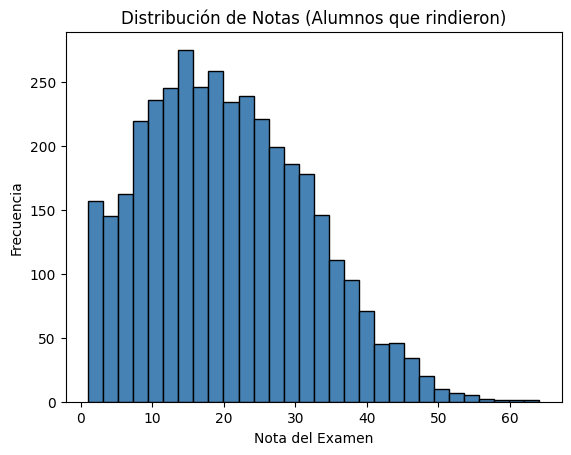

In [27]:
#Creamos dataframe solo con alumnos que rindieron el examen, es decir, que tengan una nota asignada.
df_poisson = df[(df['rindio_examen'] == 1) & (df['exam_score'] > 1.0)].copy()

# 2. Histograma (Para replicar el plt.hist de tu profe)
plt.hist(df_poisson['exam_score'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribución de Notas (Alumnos que rindieron)')
plt.xlabel('Nota del Examen')
plt.ylabel('Frecuencia')
plt.show()

Al observar el histograma, se confirma que la distribución no es perfectamente normal y es en su totalidad positiva, como Poisson funciona como un conteo de puntos obtenidos se transforma en buena opcion para modelar los datos.

In [28]:
# Definimos la ecuacion, ahora con variable Y, la nota del examen.
ecuacion_poisson = """
exam_score ~ C(academic_level, Treatment('undergraduate')) +
             study_hours + social_media_hours + gaming_hours +
             mental_health_score +
             burnout_level * sleep_hours 
"""

# Ajustar el modelo 
modelo_poisson = smf.poisson(formula=ecuacion_poisson, data=df_poisson).fit(cov_type='HC1')
print(modelo_poisson.summary())

# Predicciones 
df_poisson['ppredictions'] = modelo_poisson.predict(df_poisson).astype(float)

# Mostramos una comparativa rápida de la nota real vs la nota predicha
print("\nComparativa Real vs Predicción:")
print(df_poisson[['exam_score', 'ppredictions']].head())

Optimization terminated successfully.
         Current function value: 3.433325
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 3795
Model:                        Poisson   Df Residuals:                     3785
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.3878
Time:                        23:41:33   Log-Likelihood:                -13029.
converged:                       True   LL-Null:                       -21282.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

R: Se ejecutó un modelo Poisson filtrando la muestra exclusivamente para aquellos alumnos que efectivamente rindieron el examen (rindio_examen == 1) para observar qué variables influyen más en explicar la nota obtenida en el examen; en el caso de Poisson, los coeficientes representan cambios porcentuales en la variable Y.
Las variables escogidas, sus coeficientes, el cambio porcentual esperado en la nota y su significancia para este modelo Poisson son:

   * academic_level (High school): 0.0103 (+1.0%) | No significativa
   * academic_level (Postgraduate): 0.0002 (+0.0%) | No significativa
   * social_media_hours: -0.0418 (-4.1%) | Significativa
   * gaming_hours: -0.0287 (-2.8%) | Significativa
   * mental_health_score: 0.1116 (+11.8%) | Significativa
   * study_hours: 0.1610 (+17.5%) | Significativa
   * burnout_level: -0.0216 (-2.1%) | Significativa
   * sleep_hours: -0.0095 (-0.9%) | No significativa
   * burnout_level:sleep_hours (Interacción): 0.0008 (+0.1%) | Significativa

Al ver los coeficientes vemos que por cada hora más de estudio, la nota aumenta aproximadamente un 17.5% ($exp(0.1610) - 1$); del mismo modo, por cada punto adicional en el índice de salud mental, la nota aumenta en 11.8%. En el caso de las variables que disminuyen la nota están las horas en redes
sociales y videojuegos, con una disminución del 4.1% y 2.8% respectivamente. Vemos además que el nivel académico no influye en la nota obtenida (no es significativa).

Finalmente, vemos que la variable conjunta burnout_level * sleep_hours vuelve a ser positiva y significativa al 95% de confianza, lo que nos da a entender que las horas de sueño pueden amortiguar el efecto negativo de la carga mental en la nota que obtienen los estudiantes.

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [29]:
# 1. Obtener la predicción del modelo Poisson (lambda)
df_poisson['lambda_hat'] = modelo_poisson.predict()

# 2. Calcular la variable auxiliar usando exactamente la fórmula del profesor:
# [(y - lambda)^2 - lambda] / lambda
df_poisson['aux'] = ((df_poisson['exam_score'] - df_poisson['lambda_hat'])**2 - df_poisson['lambda_hat']) / df_poisson['lambda_hat']

# 3. Regresión auxiliar OLS (aux contra lambda_hat SIN constante, por eso el '- 1')
test_alpha = smf.ols('aux ~ lambda_hat - 1', data=df_poisson).fit()

# 4. Imprimir resultados (El coeficiente de 'lambda_hat' es tu Alpha)
print(test_alpha.summary())

                                 OLS Regression Results                                
Dep. Variable:                    aux   R-squared (uncentered):                   0.073
Model:                            OLS   Adj. R-squared (uncentered):              0.073
Method:                 Least Squares   F-statistic:                              299.6
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                    1.14e-64
Time:                        23:41:33   Log-Likelihood:                         -9432.0
No. Observations:                3795   AIC:                                  1.887e+04
Df Residuals:                    3794   BIC:                                  1.887e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

R: Uno de los supuestos fundamentales del modelo de Poisson es la equidispersión, es decir, que la media de la variable dependiente sea igual a su varianza. Si existe sobredispersión (la varianza es mayor que la media), el modelo deja de ser metodológicamente válido.

Para verificar este supuesto, se realizó un test de equidispersión que consiste en estimar una regresión MCO sin constante utilizando una variable auxiliar teórica y las predicciones ajustadas del modelo de Poisson (lambda_hat). El coeficiente resultante de esta regresión representa el parámetro de dispersión $\alpha$, cuyo valor estimado es de 0.0357.

Al observar el output, vemos que este coeficiente es altamente significativo ($p = 0.000$), por lo que se rechaza la hipótesis nula de equidispersión. Esto confirma que existe sobredispersión en las notas del examen, concluyendo así que el modelo Poisson es deficiente para estimar estos datos y se debe recurrir a un modelo Binomial Negativo para corregir la varianza inflada.

8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [30]:
df_poisson['burnout_z'] = (df_poisson['burnout_level'] - df_poisson['burnout_level'].mean()) / df_poisson['burnout_level'].std()
df_poisson['sleep_z'] = (df_poisson['sleep_hours'] - df_poisson['sleep_hours'].mean()) / df_poisson['sleep_hours'].std()

# 2. Usamos las variables estandarizadas solo en la interacción
ecuacion_nb_final = """
exam_score ~ C(academic_level, Treatment('undergraduate')) +
             study_hours + social_media_hours + gaming_hours +
             mental_health_score + 
             burnout_z * sleep_z 
"""

# 3. Ajustamos el modelo Binomial Negativo 
modelo_nb = smf.negativebinomial(formula=ecuacion_nb_final, data=df_poisson).fit(method='bfgs', maxiter=2000)

# 4. Imprimir resultados
print("=== Resultados del Modelo Binomial Negativo ===")
print(modelo_nb.summary())

Optimization terminated successfully.
         Current function value: 3.288973
         Iterations: 20
         Function evaluations: 29
         Gradient evaluations: 29
=== Resultados del Modelo Binomial Negativo ===
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 3795
Model:               NegativeBinomial   Df Residuals:                     3785
Method:                           MLE   Df Model:                            9
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.1386
Time:                        23:41:33   Log-Likelihood:                -12482.
converged:                       True   LL-Null:                       -14490.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------

R: Tras haber realizado el test y demostrado sobredispersión en los datos, se procedió a estimar un modelo Binomial Negativo utilizando las mismas variables del modelo Poisson. Sin embargo, al intentar ejecutarlo, el modelo tuvo problemas para converger debido a la complejidad computacional que conlleva la interacción de variables continuas (como burnout_level con sleep_hours) al mismo tiempo que estima el parámetro $\alpha$. Para solucionar este problema matemático sin alterar la teoría, se estandarizaron estas dos variables (pasándolas a puntuación Z o z-scores). Esto hace que las variables queden centradas en cero, estabilizando el algoritmo.

Al ejecutarlo nuevamente, el modelo convergió exitosamente. El parámetro de dispersión $\alpha$ se estimó en 0.0574, siendo altamente significativo ($p = 0.000$), lo que ratifica que la Binomial Negativa es la especificación correcta frente a Poisson.

Las variables escogidas, sus coeficientes, el cambio porcentual esperado en la nota y su significancia para este modelo Binomial Negativo son:

   * academic_level (High school): 0.0089 (+0.9%) | No significativa
   * academic_level (Postgraduate): -0.0030 (-0.3%) | No significativa
   * social_media_hours: -0.0454 (-4.4%) | Significativa
   * gaming_hours: -0.0309 (-3.0%) | Significativa
   * mental_health_score: 0.1180 (+12.5%) | Significativa
   * study_hours: 0.1729 (+18.9%) | Significativa
   * burnout_z: -0.2380 (-21.2%) | Significativa
   * sleep_z: 0.0324 (+3.3%) | Significativa
   * burnout_z:sleep_z (Interacción): 0.0120 (+1.2%) | Significativa

Al interpretar los coeficientes vemos que una hora adicional de estudio aumenta la nota esperada en un 18.9% ($exp(0.1729)-1$) y, por el contrario, una hora de uso de redes sociales disminuye la nota en un 4.4% ($exp(-0.0454)-1$). Otro coeficiente con gran influencia es el índice de salud mental, que suma un 12.5% a la nota esperada por cada aumento en una unidad de este índice.

Finalmente, la interacción propuesta de burnout_z * sleep_z mantuvo su significancia al 95% de confianza y su signo positivo. Esto comprueba que el efecto negativo de estar agotado mentalmente se amortigua con las horas de sueño (cuando estas se desvían positivamente del promedio), disminuyendo el impacto severo que el estrés conllevaría en la nota final. Dado que el nivel de agotamiento fue estandarizado, su coeficiente indica que un aumento de una desviación estándar por encima del promedio en el nivel de burnout de un alumno penaliza su nota esperada en 21.2% ($exp(-0.2380)-1$).

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

R: Al comparar los outputs de los modelos Poisson y Binomial Negativo, notamos que sus coeficientes son prácticamente idénticos; sin embargo, los errores estándar son distintos, siendo mayores en el modelo Binomial Negativo. Esto ocurre porque el modelo de Poisson asume que la media y la varianza son iguales, supuesto que comprobamos que no se cumple tras realizar un test de dispersión. Como consecuencia, en el modelo Poisson se inflan los estadísticos z, lo que lleva a pensar erróneamente que ciertas variables son más significativas. En contraste, el modelo Binomial Negativo reconoce que existe una mayor dispersión en los datos, por lo que ajusta y aumenta los errores estándar.

En mi opinión, el modelo más adecuado es el Binomial Negativo. Al corregir la deficiencia del modelo Poisson estimando simultáneamente el parámetro $\alpha$, asegura que la significancia estadística y los coeficientes de las variables sean válidos y no estén sesgados.

Para finalizar, las variables que resultaron robustas a la especificación son: study_hours, social_media_hours, gaming_hours, mental_health_score y la interacción propuesta burnout_level * sleep_hours. Esto confirma nuevamente que el ocio, las horas de estudio y el agotamiento mental son los factores que más influyen en el resultado de los estudiantes en el examen.


### Conclusion final

R: Considerando el recorrido metodológico y los resultados de ambas etapas (probabilidad de asistir y nota obtenida), las variables de: 
* Esfuerzo (estudio) 
* Ocio digital (pantallas) 
* Bienestar psico-biológico (salud mental y estrés) 

demostraron ser los determinantes estructurales, causales y estadísticamente robustos del comportamiento académico de esta muestra por lo que para un modelo definitivo a presentar deben incluirse.